# Bakery Day Backtest

Backtest notebook for bakery-level daily forecast.

Inputs:
- `reports/bakery_day_model_holdout_predictions.csv`
- `reports/bakery_day_model_bias_by_bakery.csv`

The notebook compares:
- actual sales
- base holdout forecast
- bias-adjusted holdout forecast


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

HOLDOUT_PATH = ROOT / "reports" / "bakery_day_model_holdout_predictions.csv"
BIAS_PATH = ROOT / "reports" / "bakery_day_model_bias_by_bakery.csv"
BIAS_CLIP_PCT = 0.15

holdout = pd.read_csv(HOLDOUT_PATH, encoding="utf-8-sig")
bias = pd.read_csv(BIAS_PATH, encoding="utf-8-sig")

holdout["date"] = pd.to_datetime(holdout["date"], errors="coerce")
holdout["bakery_sales"] = pd.to_numeric(holdout["bakery_sales"], errors="coerce").fillna(0.0)
holdout["bakery_day_forecast"] = pd.to_numeric(holdout["bakery_day_forecast"], errors="coerce").fillna(0.0)

bias_small = bias[["bakery_id", "bias"]].copy()
bias_small["bias"] = pd.to_numeric(bias_small["bias"], errors="coerce").fillna(0.0)
bias_small = bias_small.groupby("bakery_id", as_index=False).agg(bias=("bias", "mean"))

backtest = holdout.merge(bias_small, on="bakery_id", how="left")
backtest["bias"] = backtest["bias"].fillna(0.0)
backtest["bias_adjustment_capped"] = backtest["bias"].clip(
    lower=-backtest["bakery_day_forecast"] * BIAS_CLIP_PCT,
    upper=backtest["bakery_day_forecast"] * BIAS_CLIP_PCT,
)
backtest["bakery_day_forecast_bias_adj"] = (
    backtest["bakery_day_forecast"] + backtest["bias_adjustment_capped"]
).clip(lower=0.0)

backtest["error_base"] = backtest["bakery_sales"] - backtest["bakery_day_forecast"]
backtest["error_bias_adj"] = backtest["bakery_sales"] - backtest["bakery_day_forecast_bias_adj"]
backtest = backtest.sort_values(["bakery_id", "date"]).reset_index(drop=True)

print(f"rows={len(backtest):,} | dates={backtest['date'].nunique()} | bakeries={backtest['bakery_id'].nunique()}")
display(backtest.head())


rows=5,408 | dates=30 | bakeries=182


,date,bakery_id,bakery_name,city,bakery_sales,bakery_day_forecast,bias,bias_adjustment_capped,bakery_day_forecast_bias_adj,error_base,error_bias_adj
0,2026-04-13,1,Столичная 37А Зеленодольск,Зеленодольск,759.0,912.477850,-9.978048,-9.978048,902.499802,-153.477850,-143.499802
1,2026-04-14,1,Столичная 37А Зеленодольск,Зеленодольск,779.0,909.473469,-9.978048,-9.978048,899.495421,-130.473469,-120.495421
2,2026-04-15,1,Столичная 37А Зеленодольск,Зеленодольск,820.0,922.719155,-9.978048,-9.978048,912.741108,-102.719155,-92.741108
3,2026-04-16,1,Столичная 37А Зеленодольск,Зеленодольск,938.5,924.755896,-9.978048,-9.978048,914.777848,13.744104,23.722152
4,2026-04-17,1,Столичная 37А Зеленодольск,Зеленодольск,931.5,1029.905230,-9.978048,-9.978048,1019.927183,-98.405230,-88.427183


In [3]:
def metrics_frame(df: pd.DataFrame, actual_col: str, pred_cols: list[str]) -> pd.DataFrame:
    rows = []
    actual = pd.to_numeric(df[actual_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    for pred_col in pred_cols:
        pred = pd.to_numeric(df[pred_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        rows.append(
            {
                "model": pred_col,
                "mae": float(np.mean(np.abs(actual - pred))),
                "mse": float(np.mean((actual - pred) ** 2)),
                "wmape": float(np.sum(np.abs(actual - pred)) / (np.sum(actual) + 1e-8) * 100),
                "bias": float(np.mean(actual - pred)),
                "forecast_total": float(pred.sum()),
                "actual_total": float(actual.sum()),
            }
        )
    return pd.DataFrame(rows)


overall_metrics = metrics_frame(
    backtest,
    actual_col="bakery_sales",
    pred_cols=["bakery_day_forecast", "bakery_day_forecast_bias_adj"],
)
display(overall_metrics)


,model,mae,mse,wmape,bias,forecast_total,actual_total
0,bakery_day_forecast,120.815491,30548.869505,11.059075,-4.071559,5.930019e+06,5908000.303
1,bakery_day_forecast_bias_adj,116.979183,29115.777237,10.707911,-0.055495,5.908300e+06,5908000.303


In [4]:
daily = (
    backtest.groupby("date", as_index=False)
    .agg(
        actual=("bakery_sales", "sum"),
        forecast_base=("bakery_day_forecast", "sum"),
        forecast_bias_adj=("bakery_day_forecast_bias_adj", "sum"),
    )
    .sort_values("date")
)
daily["error_base"] = daily["actual"] - daily["forecast_base"]
daily["error_bias_adj"] = daily["actual"] - daily["forecast_bias_adj"]
display(daily.head())


,date,actual,forecast_base,forecast_bias_adj,error_base,error_bias_adj
0,2026-04-13,178492.186,202972.883271,202214.920760,-24480.697271,-23722.734760
1,2026-04-14,188387.273,206186.968311,205429.005800,-17799.695311,-17041.732800
2,2026-04-15,204920.761,212379.221229,211621.258718,-7458.460229,-6700.497718
3,2026-04-16,209222.510,215628.492465,214870.529954,-6405.982465,-5648.019954
4,2026-04-17,223097.940,235569.423483,234811.460972,-12471.483483,-11713.520972


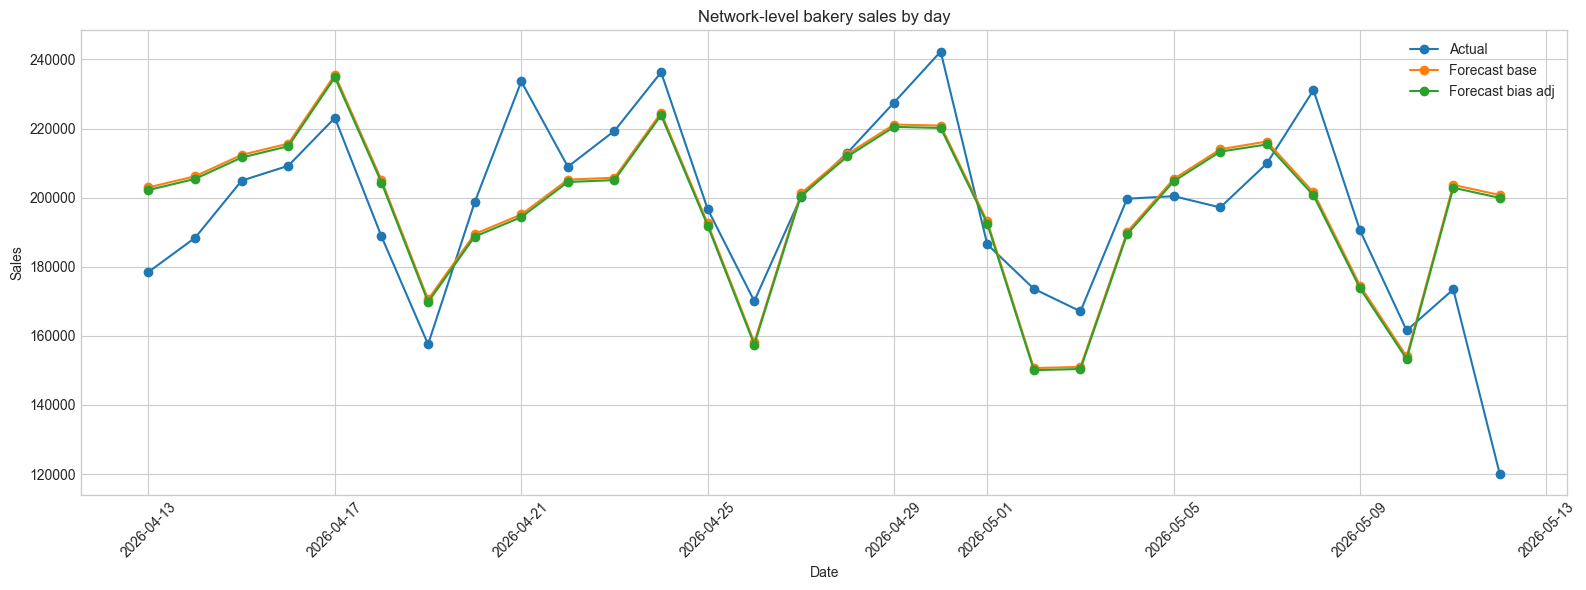

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily["date"], daily["actual"], marker="o", label="Actual")
ax.plot(daily["date"], daily["forecast_base"], marker="o", label="Forecast base")
ax.plot(daily["date"], daily["forecast_bias_adj"], marker="o", label="Forecast bias adj")
ax.set_title("Network-level bakery sales by day")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


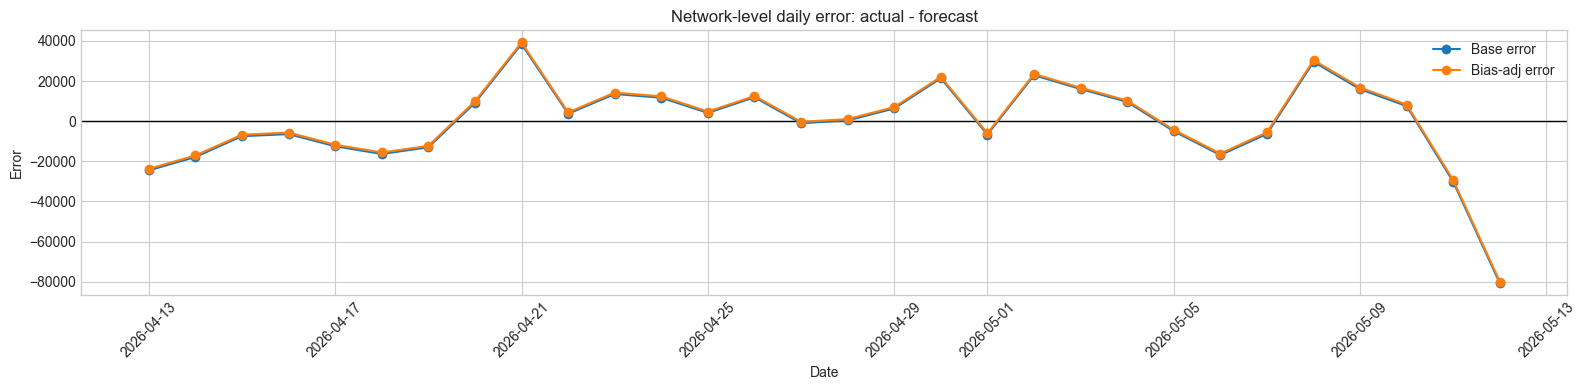

In [6]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.axhline(0.0, color="black", linewidth=1)
ax.plot(daily["date"], daily["error_base"], marker="o", label="Base error")
ax.plot(daily["date"], daily["error_bias_adj"], marker="o", label="Bias-adj error")
ax.set_title("Network-level daily error: actual - forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Error")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
bias_view = bias.copy().sort_values("abs_bias", ascending=False).reset_index(drop=True)
display(bias_view.head(20))


,bakery_id,bakery_name,city,n_days,actual_mean,forecast_mean,bias,mae,actual_sum,forecast_sum,abs_bias,bias_pct_of_actual_mean,wmape
0,262,Харьковская 3 Курск,Курск,30,1052.083333,1230.375210,-178.291877,220.904958,31562.500,36911.256312,178.291877,-16.946555,20.996907
1,142,Баки Урманче 6 Казань,Казань,30,2022.263167,2165.794616,-143.531449,190.485925,60667.895,64973.838473,143.531449,-7.097565,9.419443
2,245,"Яблоневая, 1д Габишево",Казань,30,1144.107033,1025.594432,118.512601,186.307431,34323.211,30767.832964,118.512601,10.358524,16.284091
3,249,Союзная 21 Курск,Курск,30,989.300000,1094.984582,-105.684582,148.413894,29679.000,32849.537459,105.684582,-10.682764,15.001910
4,18,Хади Такташ 105 Казань,Казань,30,1652.707500,1751.131277,-98.423777,196.199230,49581.225,52533.938314,98.423777,-5.955305,11.871383
5,231,Клыкова 92 Курск,Курск,30,844.616667,939.140918,-94.524251,148.109298,25338.500,28174.227531,94.524251,-11.191379,17.535683
6,60,Мусина 68 Казань,Казань,30,3053.533333,2963.072182,90.461151,280.998767,91606.000,88892.165473,90.461151,2.962507,9.202414
7,103,Татарстан 16 Наб Челны,Набережные Челны,30,1258.703167,1173.594576,85.108591,142.811695,37761.095,35207.837271,85.108591,6.761609,11.345939
8,116,Горького 51 Чебоксары,Чебоксары,30,1754.990000,1835.960049,-80.970049,216.697307,52649.700,55078.801483,80.970049,-4.613704,12.347495
9,86,Лемаева 2А Нижнекамск,Нижнекамск,30,1072.683900,1002.378677,70.305223,197.764795,32180.517,30071.360310,70.305223,6.554142,18.436447


In [8]:
def plot_bakery(bakery_id=None, bakery_name_contains=None):
    work = backtest.copy()
    if bakery_id is not None:
        work = work[work["bakery_id"] == bakery_id].copy()
    if bakery_name_contains is not None:
        work = work[work["bakery_name"].str.contains(bakery_name_contains, case=False, na=False)].copy()
    if work.empty:
        raise ValueError("No rows found for the requested bakery filter")

    bakery_name = work["bakery_name"].iloc[0]
    bakery_id_value = work["bakery_id"].iloc[0]
    city = work["city"].iloc[0]

    metrics = metrics_frame(
        work,
        actual_col="bakery_sales",
        pred_cols=["bakery_day_forecast", "bakery_day_forecast_bias_adj"],
    )
    display(metrics)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    axes[0].plot(work["date"], work["bakery_sales"], marker="o", label="Actual")
    axes[0].plot(work["date"], work["bakery_day_forecast"], marker="o", label="Forecast base")
    axes[0].plot(work["date"], work["bakery_day_forecast_bias_adj"], marker="o", label="Forecast bias adj")
    axes[0].set_title(f"Bakery {bakery_id_value} | {bakery_name} | {city}")
    axes[0].set_ylabel("Sales")
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].plot(work["date"], work["error_base"], marker="o", label="Base error")
    axes[1].plot(work["date"], work["error_bias_adj"], marker="o", label="Bias-adj error")
    axes[1].set_ylabel("Error")
    axes[1].set_xlabel("Date")
    axes[1].legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


,model,mae,mse,wmape,bias,forecast_total,actual_total
0,bakery_day_forecast,124.59227,36669.969362,7.100893,1.596854e+01,52158.94389,52638.0
1,bakery_day_forecast_bias_adj,125.16761,36414.975188,7.133683,-9.852859e-14,52638.00000,52638.0


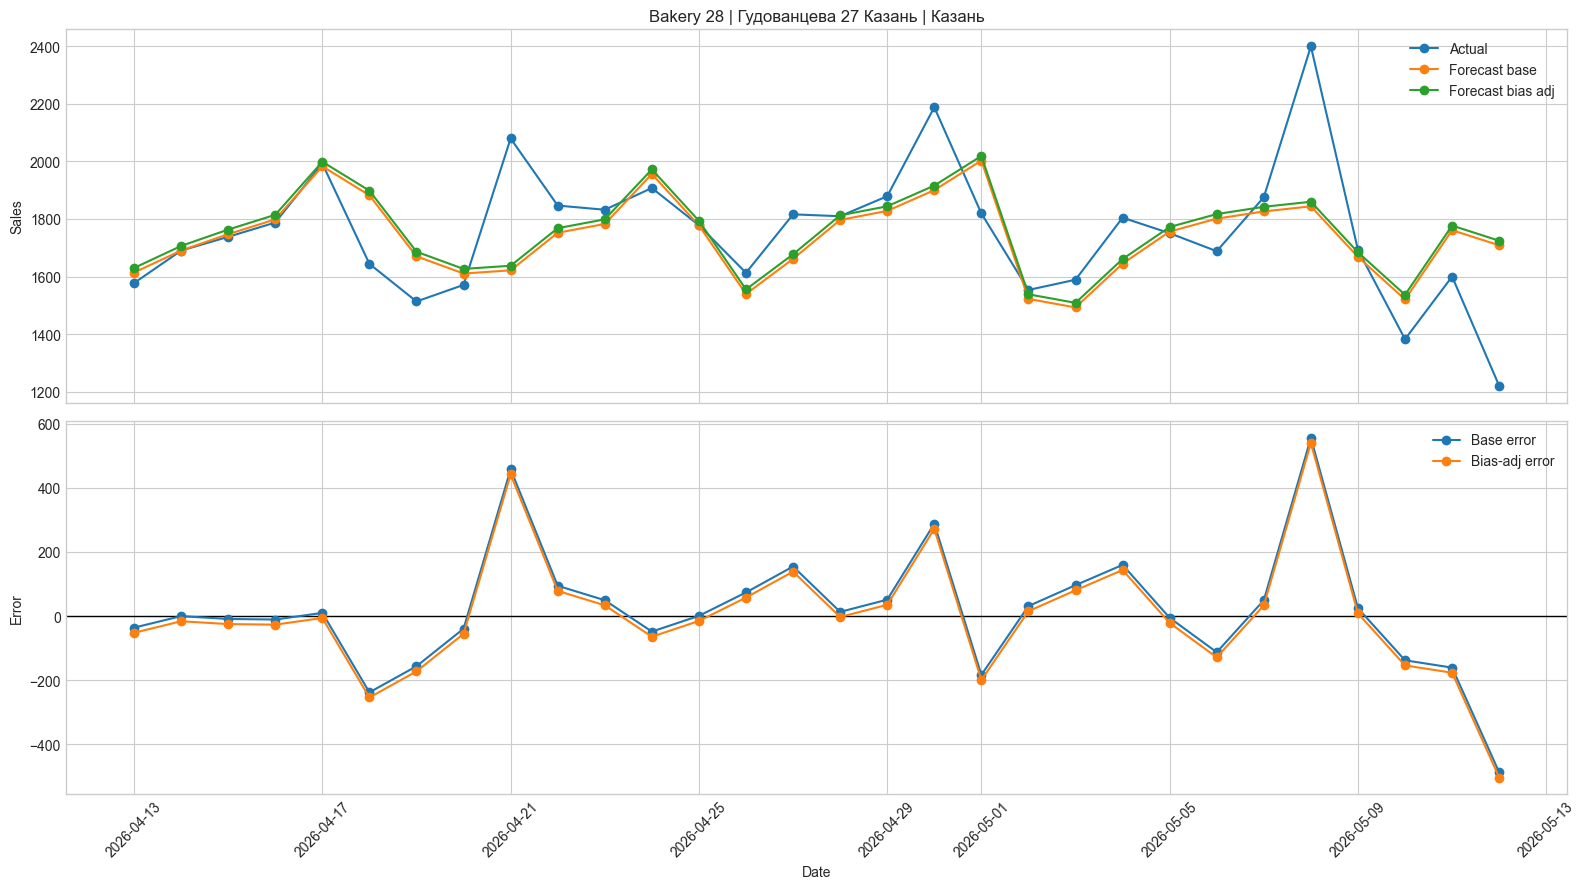

,model,mae,mse,wmape,bias,forecast_total,actual_total
0,bakery_day_forecast,186.307431,62042.534796,16.284091,1.185126e+02,30767.832964,34323.211
1,bakery_day_forecast_bias_adj,163.208807,47997.298152,14.265169,-1.515825e-14,34323.211000,34323.211


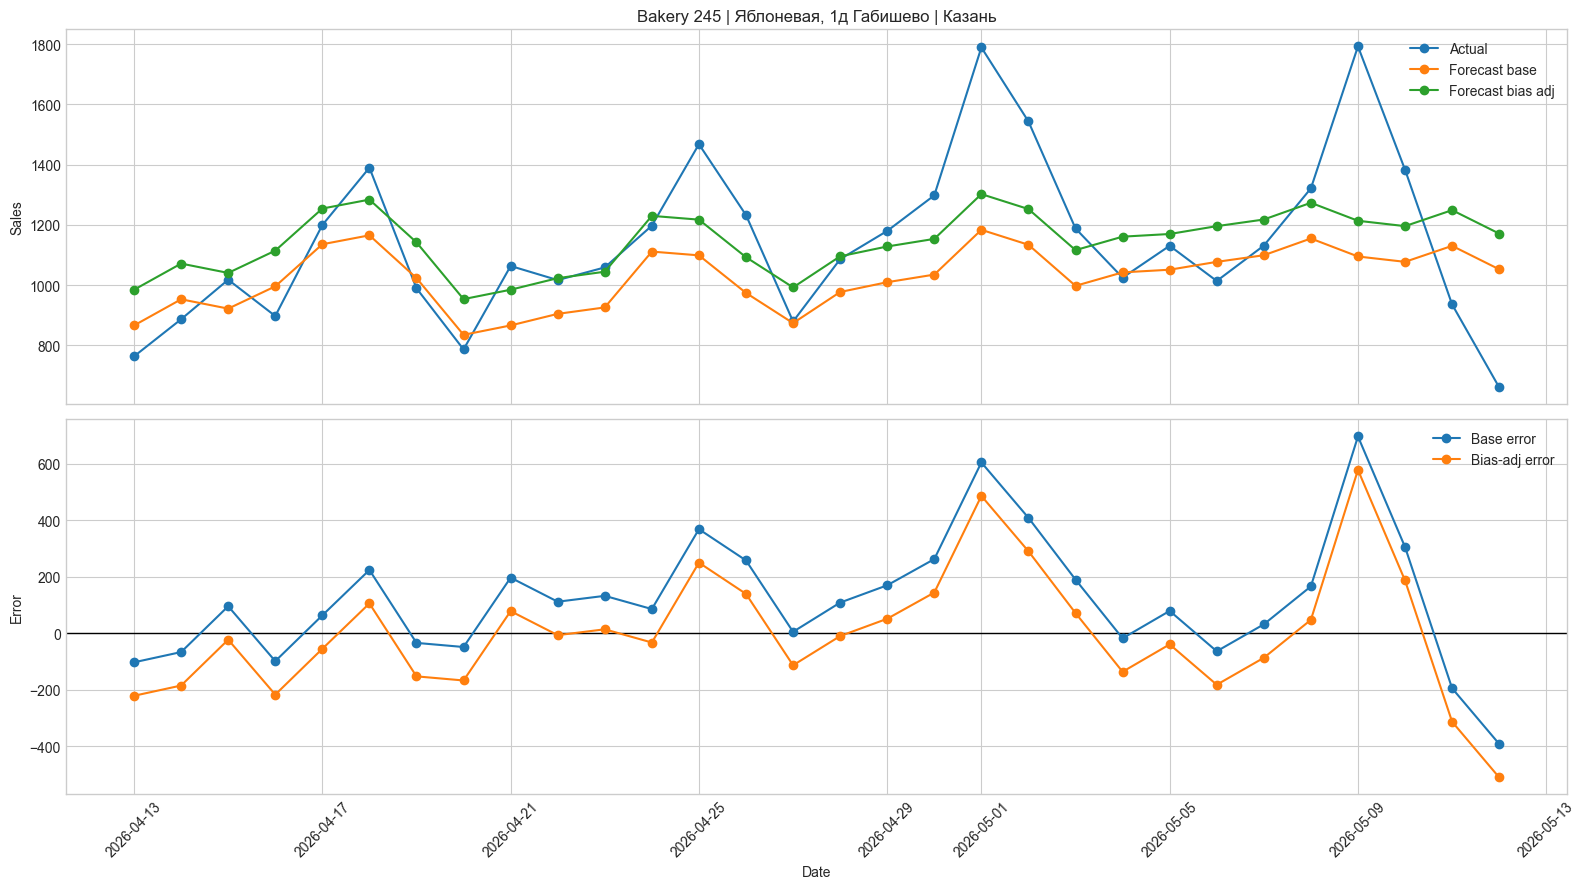

In [42]:
# Examples: inspect the strongest shifted bakeries from holdout.
plot_bakery(bakery_id=28)
plot_bakery(bakery_id=245)


In [10]:
bakery_metrics = []
for bakery_id, group in backtest.groupby("bakery_id", sort=False):
    metric_df = metrics_frame(group, "bakery_sales", ["bakery_day_forecast", "bakery_day_forecast_bias_adj"])
    base = metric_df[metric_df["model"] == "bakery_day_forecast"].iloc[0]
    adj = metric_df[metric_df["model"] == "bakery_day_forecast_bias_adj"].iloc[0]
    bakery_metrics.append(
        {
            "bakery_id": bakery_id,
            "bakery_name": group["bakery_name"].iloc[0],
            "city": group["city"].iloc[0],
            "base_mae": base["mae"],
            "adj_mae": adj["mae"],
            "mae_delta": adj["mae"] - base["mae"],
            "base_bias": base["bias"],
            "adj_bias": adj["bias"],
            "abs_bias_delta": abs(adj["bias"]) - abs(base["bias"]),
        }
    )

bakery_metrics = pd.DataFrame(bakery_metrics)
print("Bias-adjusted forecast improved MAE for bakeries:", int((bakery_metrics['mae_delta'] < 0).sum()))
print("Bias-adjusted forecast reduced abs(bias) for bakeries:", int((bakery_metrics['abs_bias_delta'] < 0).sum()))
display(bakery_metrics.sort_values("mae_delta").head(20))
display(bakery_metrics.sort_values("mae_delta", ascending=False).head(20))


Bias-adjusted forecast improved MAE for bakeries: 128
Bias-adjusted forecast reduced abs(bias) for bakeries: 182


,bakery_id,bakery_name,city,base_mae,adj_mae,mae_delta,base_bias,adj_bias,abs_bias_delta
176,262,Харьковская 3 Курск,Курск,220.904958,146.124383,-74.780575,-178.291877,-6.841357e+00,-171.450521
83,103,Татарстан 16 Наб Челны,Набережные Челны,142.811695,100.859163,-41.952532,85.108591,9.852859e-14,-85.108591
166,249,Союзная 21 Курск,Курск,148.413894,116.225451,-32.188443,-105.684582,1.894781e-14,-105.684582
147,218,Проспект Победы 147 Казань,Казань,93.048538,63.434819,-29.613719,64.772760,2.652693e-14,-64.772760
164,245,"Яблоневая, 1д Габишево",Казань,186.307431,163.208807,-23.098624,118.512601,-1.515825e-14,-118.512601
117,160,Альфии Авзаловой 5 Казань,Казань,137.802639,116.828492,-20.974146,59.797861,-3.789561e-15,-59.797861
95,117,Дубравная 51Г Казань,Казань,256.419546,236.111674,-20.307872,46.761688,-1.440033e-13,-46.761688
103,142,Баки Урманче 6 Казань,Казань,190.485925,171.563585,-18.922341,-143.531449,9.094947e-14,-143.531449
155,231,Клыкова 92 Курск,Курск,148.109298,131.033261,-17.076037,-94.524251,-3.373458e-01,-94.186905
61,72,Сахарова 27 Казань,Казань,116.234285,99.907452,-16.326833,-65.196998,4.547474e-14,-65.196998


,bakery_id,bakery_name,city,base_mae,adj_mae,mae_delta,base_bias,adj_bias,abs_bias_delta
78,94,Розы Люксембург 4 Чебоксары,Чебоксары,126.156056,130.643880,4.487824,-35.845249,-1.136868e-13,-35.845249
110,152,Менделеева 35А Нижнекамск,Нижнекамск,85.355503,89.800098,4.444595,-23.772250,3.221127e-14,-23.772250
43,48,Гаврилова 40 Казань,Казань,98.449781,102.669966,4.220184,23.447280,1.894781e-14,-23.447280
9,11,Фучика 72 Казань,Казань,149.283296,152.845114,3.561817,32.649012,-4.168517e-14,-32.649012
79,95,Сармановский тракт 18/38А Наб Челны,Набережные Челны,136.030134,139.343703,3.313568,-30.752188,-1.136868e-14,-30.752188
59,70,Комсомольская 52Б Заинск,Заинск,164.013768,166.987755,2.973987,-25.896496,1.515825e-14,-25.896496
0,1,Столичная 37А Зеленодольск,Зеленодольск,90.637685,93.298498,2.660813,-9.978048,-1.136868e-14,-9.978048
102,137,Татарстан 53А Казань,Казань,201.665343,204.194829,2.529486,-24.475378,9.094947e-14,-24.475378
126,172,Винокурова 28 Новочебоксарск,Чебоксары,119.966465,122.424613,2.458148,-13.459272,3.789561e-14,-13.459272
73,89,Парина 6 Казань,Казань,181.809695,184.110961,2.301265,-12.220612,3.789561e-15,-12.220612


bakery_id=245 | Яблоневая, 1д Габишево | Казань


,model,mae,bias,actual_mean,forecast_mean
0,baseline,186.307431,118.512601,1144.107033,1025.594432
1,fast_seasonal,177.480455,122.153632,1144.107033,1021.953401


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,763.560,866.140747,828.992225,-102.580747,-65.432225
1,2026-04-14,886.720,953.004173,856.909219,-66.284173,29.810781
2,2026-04-15,1017.965,921.984236,877.670908,95.980764,140.294092
3,2026-04-16,897.455,995.920781,971.432756,-98.465781,-73.977756
4,2026-04-17,1199.357,1135.608334,1064.946960,63.748666,134.410040
5,2026-04-18,1389.715,1165.296705,990.377773,224.418295,399.337227
6,2026-04-19,989.575,1023.420429,975.379924,-33.845429,14.195076
7,2026-04-20,786.620,835.011079,772.745254,-48.391079,13.874746
8,2026-04-21,1063.481,866.244907,859.460499,197.236093,204.020501
9,2026-04-22,1016.692,904.643934,943.567748,112.048066,73.124252


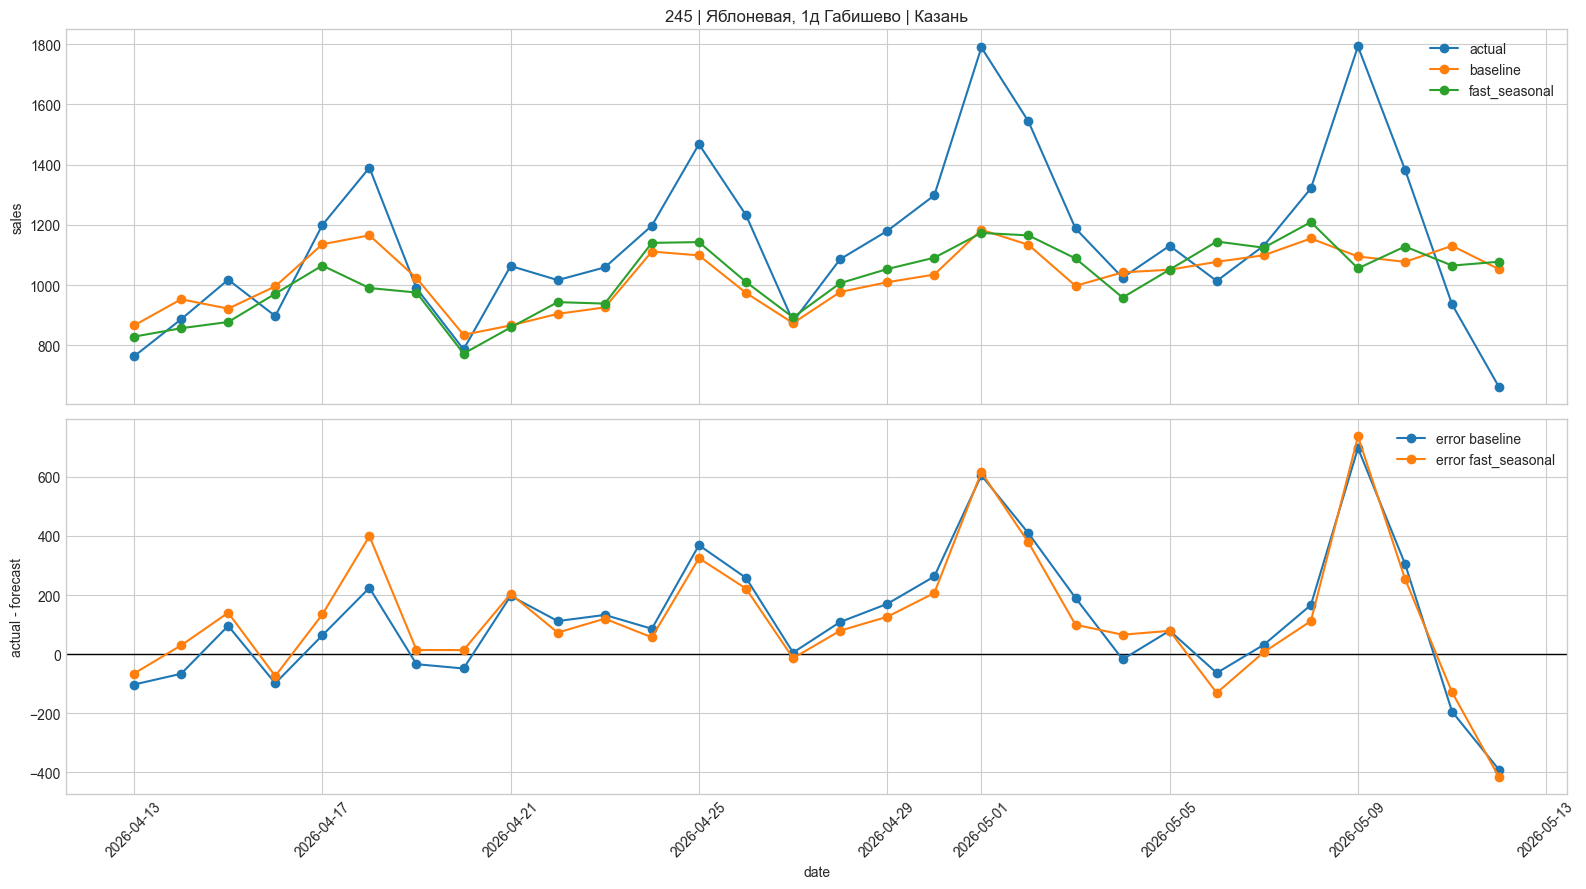

bakery_id=262 | Харьковская 3 Курск | Курск


,model,mae,bias,actual_mean,forecast_mean
0,baseline,220.904958,-178.291877,1052.083333,1230.375210
1,fast_seasonal,194.241416,-109.832266,1052.083333,1161.915599


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,948.0,1412.682165,1158.723504,-464.682165,-210.723504
1,2026-04-14,1057.0,1274.937489,1122.475640,-217.937489,-65.475640
2,2026-04-15,929.0,1248.704941,1197.389771,-319.704941,-268.389771
3,2026-04-16,917.0,1360.658871,1255.713243,-443.658871,-338.713243
4,2026-04-17,1177.0,1628.259008,1519.874756,-451.259008,-342.874756
5,2026-04-18,1557.0,1421.738303,1206.934487,135.261697,350.065513
6,2026-04-19,983.0,1333.892797,1140.585753,-350.892797,-157.585753
7,2026-04-20,1470.0,1198.655887,1004.243308,271.344113,465.756692
8,2026-04-21,1065.0,1424.980108,1288.511957,-359.980108,-223.511957
9,2026-04-22,1036.0,1280.422269,1103.827660,-244.422269,-67.827660


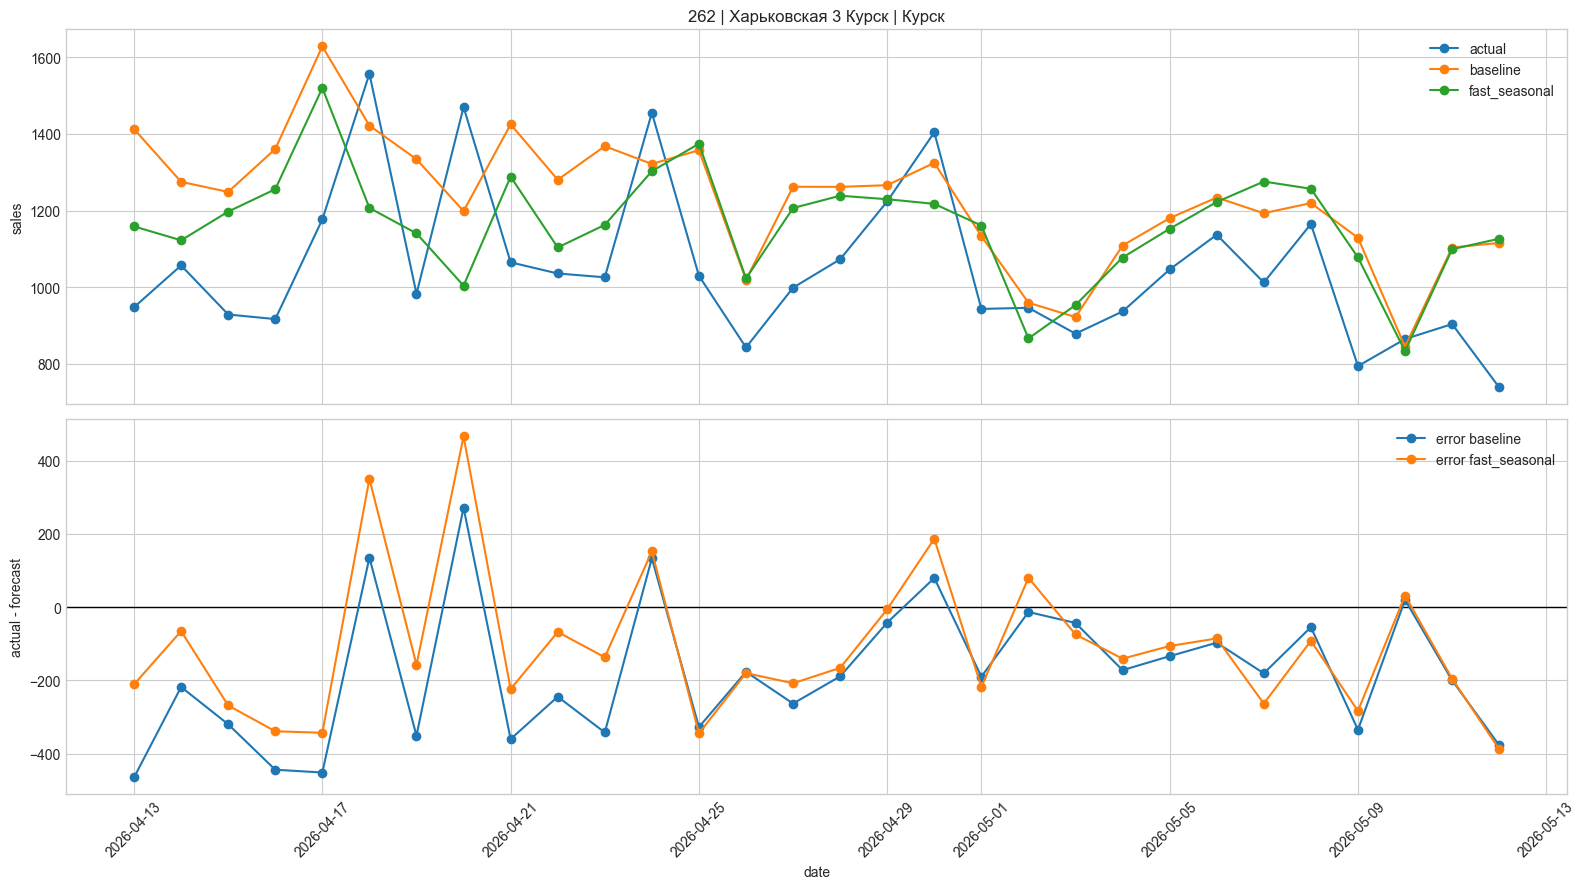

bakery_id=60 | Мусина 68 Казань | Казань


,model,mae,bias,actual_mean,forecast_mean
0,baseline,280.998767,90.461151,3053.533333,2963.072182
1,fast_seasonal,411.164857,251.355389,3053.533333,2802.177945


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,2632.0,2689.610124,1950.799224,-57.610124,681.200776
1,2026-04-14,2798.0,2738.774603,2052.206646,59.225397,745.793354
2,2026-04-15,2881.0,2925.948384,2229.382615,-44.948384,651.617385
3,2026-04-16,2822.0,3016.566820,2252.723217,-194.566820,569.276783
4,2026-04-17,3786.0,3209.667133,2417.855532,576.332867,1368.144468
5,2026-04-18,3038.0,3107.872106,2056.593252,-69.872106,981.406748
6,2026-04-19,2930.0,2820.337428,1993.076324,109.662572,936.923676
7,2026-04-20,2794.0,2788.421565,2705.147500,5.578435,88.852500
8,2026-04-21,3624.0,3007.202899,2983.067074,616.797101,640.932926
9,2026-04-22,3014.0,2968.781362,3246.372314,45.218638,-232.372314


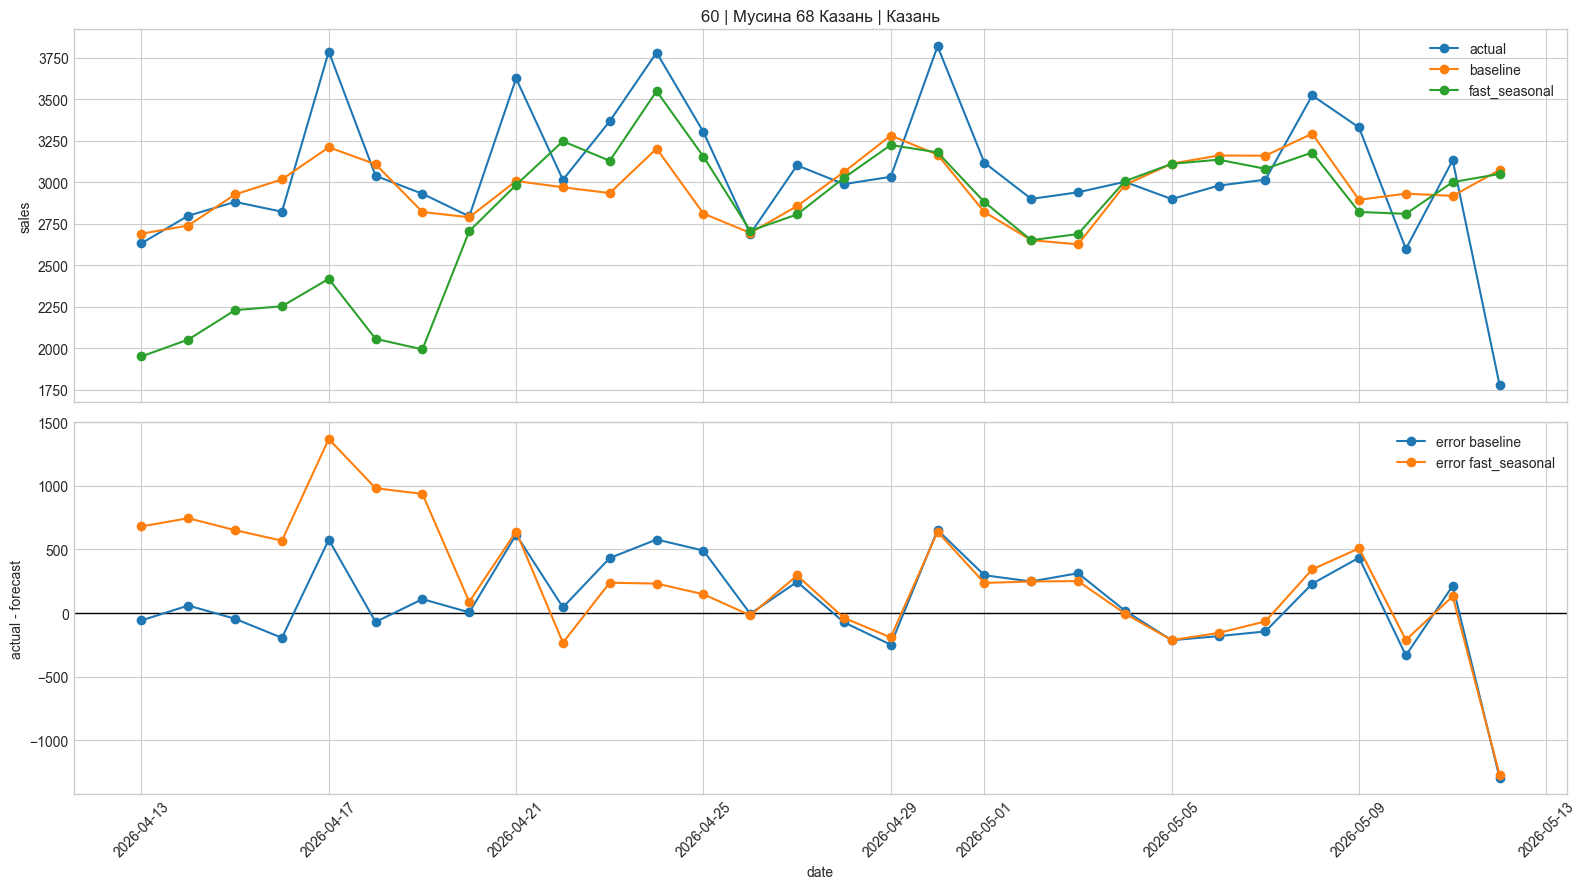

bakery_id=122 | Проспект Победы 46В Казань | Казань


,model,mae,bias,actual_mean,forecast_mean
0,baseline,112.11132,-3.091612,983.2457,986.337312
1,fast_seasonal,113.26181,23.826945,983.2457,959.418755


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,977.191,1043.567267,1003.874132,-66.376267,-26.683132
1,2026-04-14,1075.048,1088.927109,1016.487741,-13.879109,58.560259
2,2026-04-15,1057.931,1131.994255,1053.267056,-74.063255,4.663944
3,2026-04-16,1152.802,1138.840090,1067.162258,13.961910,85.639742
4,2026-04-17,1007.232,1255.383926,1147.923609,-248.151926,-140.691609
5,2026-04-18,962.287,1066.199927,895.013724,-103.912927,67.273276
6,2026-04-19,597.384,846.240145,741.142212,-248.856145,-143.758212
7,2026-04-20,1057.011,976.641367,917.263722,80.369633,139.747278
8,2026-04-21,1172.527,1003.202283,978.358598,169.324717,194.168402
9,2026-04-22,1017.109,1038.667472,1034.562879,-21.558472,-17.453879


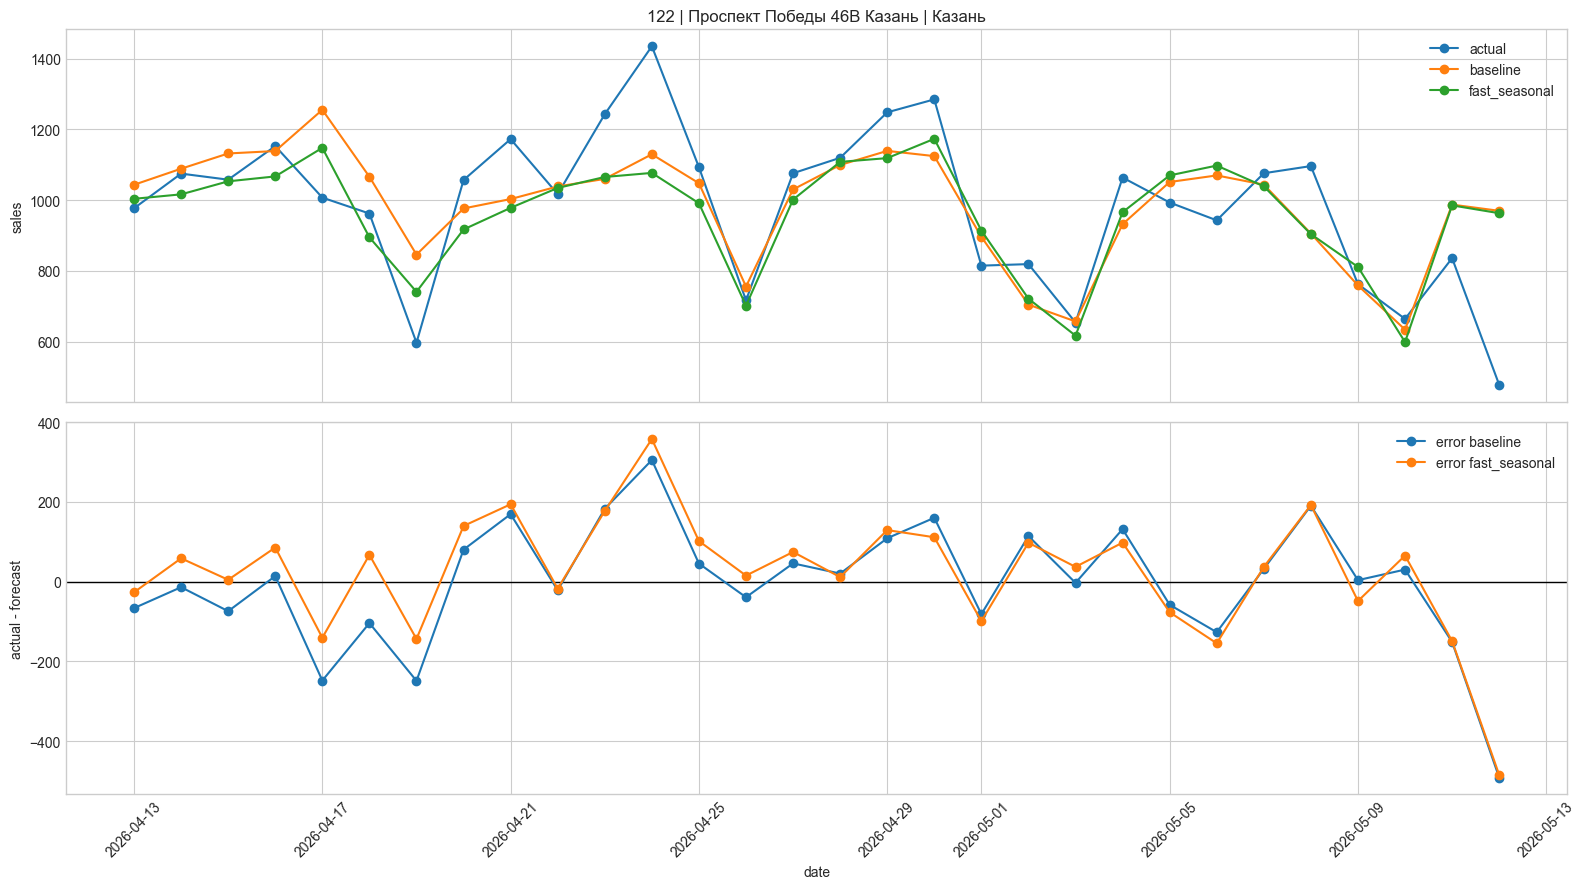

bakery_id=128: no rows
bakery_id=129: no rows
bakery_id=127: no rows
bakery_id=130 | Сармановский тракт 68 Наб Челны | Набережные Челны


,model,mae,bias,actual_mean,forecast_mean
0,baseline,72.533311,8.240207,664.649467,656.409260
1,fast_seasonal,67.152669,23.725246,664.649467,640.924221


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,606.224,675.505218,608.169029,-69.281218,-1.945029
1,2026-04-14,547.888,668.615905,636.643267,-120.727905,-88.755267
2,2026-04-15,626.673,698.446244,645.724535,-71.773244,-19.051535
3,2026-04-16,655.943,700.210168,675.329090,-44.267168,-19.386090
4,2026-04-17,706.359,756.297656,714.088084,-49.938656,-7.729084
5,2026-04-18,639.930,686.012099,620.081132,-46.082099,19.848868
6,2026-04-19,497.513,584.781375,575.273629,-87.268375,-77.760629
7,2026-04-20,593.850,619.667269,586.568740,-25.817269,7.281260
8,2026-04-21,777.472,607.238797,570.672661,170.233203,206.799339
9,2026-04-22,722.840,653.848502,640.427765,68.991498,82.412235


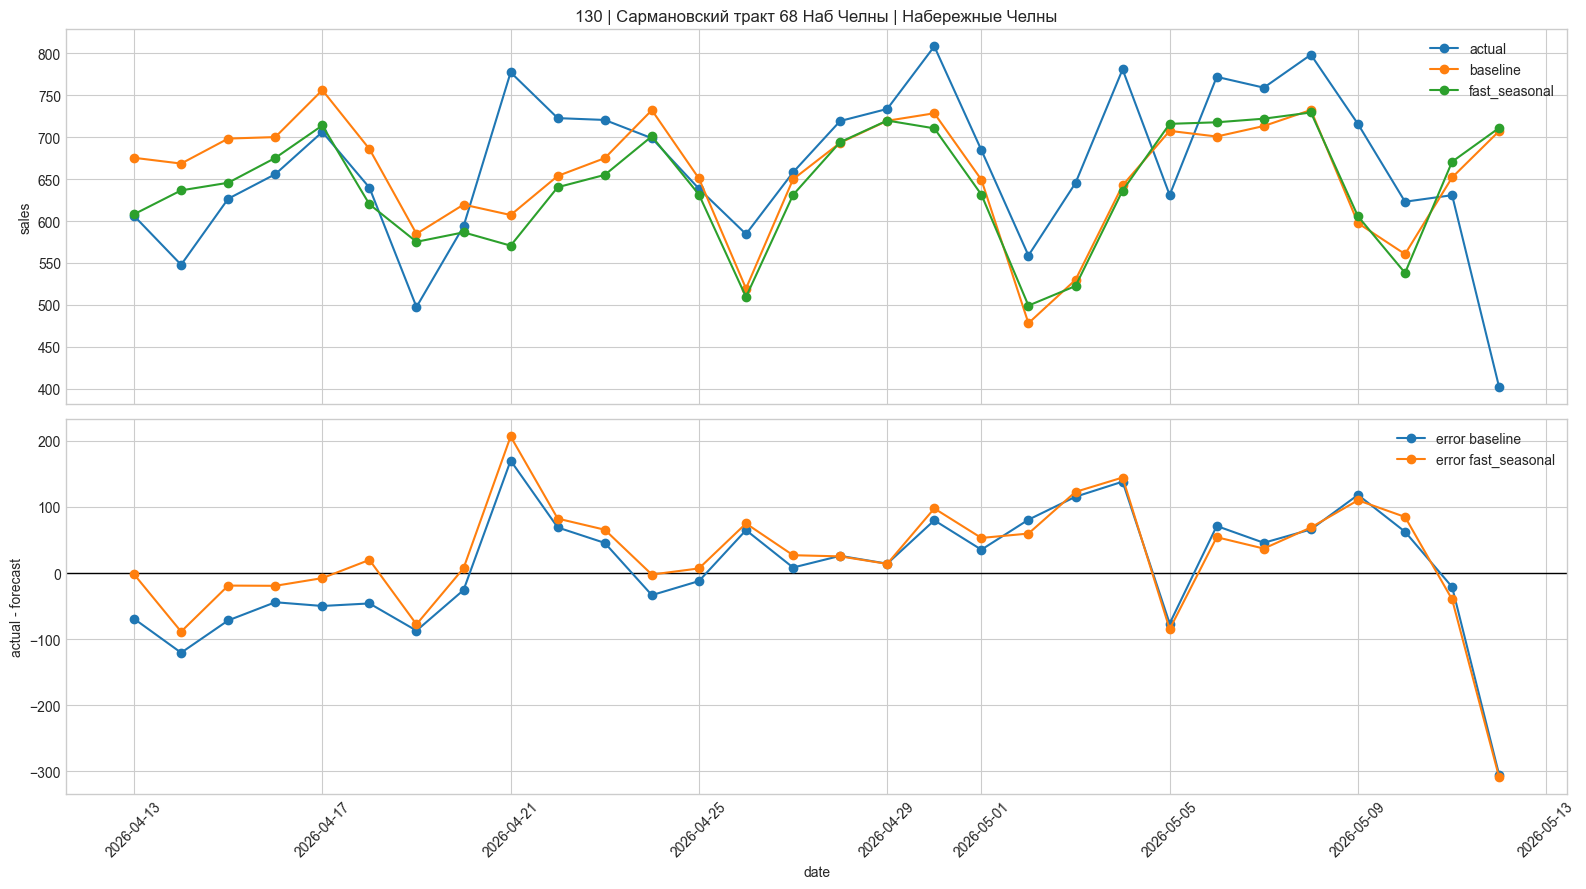

bakery_id=131: no rows
bakery_id=132: no rows


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

base = pd.read_csv(
    ROOT / "src" / "experiments_v2" / "72_bakery_regime_shift" / "predictions_baseline_global_lgbm.csv",
    encoding="utf-8-sig",
)
fast = pd.read_csv(
    ROOT / "src" / "experiments_v2" / "72_bakery_regime_shift" / "predictions_fast_seasonal_lgbm.csv",
    encoding="utf-8-sig",
)

for df in [base, fast]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

cmp_df = base.merge(
    fast[["date", "bakery_id", "prediction"]].rename(columns={"prediction": "pred_fast"}),
    on=["date", "bakery_id"],
    how="inner",
)
cmp_df = cmp_df.rename(columns={"prediction": "pred_base"})
cmp_df["err_base"] = cmp_df["bakery_sales"] - cmp_df["pred_base"]
cmp_df["err_fast"] = cmp_df["bakery_sales"] - cmp_df["pred_fast"]
cmp_df.head()

def show_bakery_compare(bakery_id: int):
    sub = cmp_df[cmp_df["bakery_id"] == bakery_id].sort_values("date").copy()
    if sub.empty:
        print(f"bakery_id={bakery_id}: no rows")
        return

    bakery_name = sub["bakery_name"].iloc[0]
    city = sub["city"].iloc[0]

    metrics = pd.DataFrame(
        [
            {
                "model": "baseline",
                "mae": sub["err_base"].abs().mean(),
                "bias": sub["err_base"].mean(),
                "actual_mean": sub["bakery_sales"].mean(),
                "forecast_mean": sub["pred_base"].mean(),
            },
            {
                "model": "fast_seasonal",
                "mae": sub["err_fast"].abs().mean(),
                "bias": sub["err_fast"].mean(),
                "actual_mean": sub["bakery_sales"].mean(),
                "forecast_mean": sub["pred_fast"].mean(),
            },
        ]
    )

    print(f"bakery_id={bakery_id} | {bakery_name} | {city}")
    display(metrics)
    display(
        sub[
            ["date", "bakery_sales", "pred_base", "pred_fast", "err_base", "err_fast"]
        ].reset_index(drop=True)
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

    axes[0].plot(sub["date"], sub["bakery_sales"], marker="o", label="actual")
    axes[0].plot(sub["date"], sub["pred_base"], marker="o", label="baseline")
    axes[0].plot(sub["date"], sub["pred_fast"], marker="o", label="fast_seasonal")
    axes[0].set_title(f"{bakery_id} | {bakery_name} | {city}")
    axes[0].set_ylabel("sales")
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].plot(sub["date"], sub["err_base"], marker="o", label="error baseline")
    axes[1].plot(sub["date"], sub["err_fast"], marker="o", label="error fast_seasonal")
    axes[1].set_ylabel("actual - forecast")
    axes[1].set_xlabel("date")
    axes[1].legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for bakery_id in [245, 262, 60, 122, 128, 129, 127, 130, 131, 132]:
    show_bakery_compare(bakery_id)